In [2]:
import pandas as pd
df=pd.read_csv('../sukkiri-ml2-codes/datafiles/Boston.csv')
df.head(2)

,CRIME,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,LSTAT,PRICE
0,high,0.0,18.10,0,0.718,3.561,87.9,1.6132,24.0,666,20.2,7.12,27.5
1,low,0.0,8.14,0,0.538,5.950,82.0,3.9900,4.0,307,21.0,27.71,13.2


In [3]:
#ダミー変数化
df2=df.fillna(df.mean(numeric_only=True))

dummy=pd.get_dummies(df2['CRIME'],drop_first=True,dtype=int)
df3=df2.join(dummy)
df3=df3.drop(['CRIME'],axis=1)

df3.head(2)

,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,LSTAT,PRICE,low,very_low
0,0.0,18.10,0,0.718,3.561,87.9,1.6132,24.0,666,20.2,7.12,27.5,0,0
1,0.0,8.14,0,0.538,5.950,82.0,3.9900,4.0,307,21.0,27.71,13.2,1,0


In [4]:
#標準化
from sklearn.preprocessing import StandardScaler

df4=df3.astype('float')
sc=StandardScaler()
sc_df=sc.fit_transform(df4)

In [5]:
#主成分分析の実施
from sklearn.decomposition import PCA
model=PCA(n_components=2,whiten=True)  #モデルの作成

model.fit(sc_df)  #モデルに学習させる

,n_components,2
,copy,True
,whiten,True
,svd_solver,'auto'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,None


In [6]:
print(f'第１主成分{model.components_[0]}')
print(f'第２主成分{model.components_[1]}')

第１主成分[-0.23265443  0.36616284  0.04517974  0.35503904 -0.20084616  0.30527702
 -0.30707163  0.30948249  0.33128121  0.16496587  0.27862981 -0.20302074
  0.04112365 -0.32030142]
第２主成分[-0.14681922  0.02281697  0.19632056  0.13501227  0.41326429  0.194608
 -0.28852895 -0.10302306 -0.11673939 -0.34444414 -0.18315489  0.44817178
  0.42053215 -0.27406254]


In [7]:
new=model.transform(sc_df)
new_df=pd.DataFrame(new)
new_df.head(3)

,0,1
0,1.517109,-0.708638
1,0.548444,-0.185088
2,-1.426543,-0.586736


In [8]:
new_df.columns=['PC1','PC2']
#標準化済みの既存データ（numpy）をデータフレーム化
df5=pd.DataFrame(sc_df,columns=df4.columns)
#2つのデータフレームを列方向に結合
df6=pd.concat([df5,new_df],axis=1)

In [9]:
df_corr=df6.corr()
df_corr.loc[:'very_low','PC1':]

,PC1,PC2
ZN,-0.569300,-0.216191
INDUS,0.895993,0.033598
CHAS,0.110554,0.289082
NOX,0.868773,0.198806
RM,-0.491466,0.608532
AGE,0.747006,0.286560
DIS,-0.751398,-0.424859
RAD,0.757297,-0.151701
TAX,0.810638,-0.171899
PTRATIO,0.403668,-0.507194


In [10]:
pc_corr=df_corr.loc[:'very_low','PC1':]
pc_corr['PC1'].sort_values(ascending=False)

INDUS       0.895993
NOX         0.868773
TAX         0.810638
RAD         0.757297
AGE         0.747006
LSTAT       0.681801
PTRATIO     0.403668
CHAS        0.110554
low         0.100629
RM         -0.491466
PRICE      -0.496787
ZN         -0.569300
DIS        -0.751398
very_low   -0.783771
Name: PC1, dtype: float64

In [11]:
pc_corr['PC2'].sort_values(ascending=False)

PRICE       0.659933
low         0.619234
RM          0.608532
CHAS        0.289082
AGE         0.286560
NOX         0.198806
INDUS       0.033598
RAD        -0.151701
TAX        -0.171899
ZN         -0.216191
LSTAT      -0.269696
very_low   -0.403557
DIS        -0.424859
PTRATIO    -0.507194
Name: PC2, dtype: float64

<Axes: xlabel='Countryside', ylabel='Exclusive residential'>

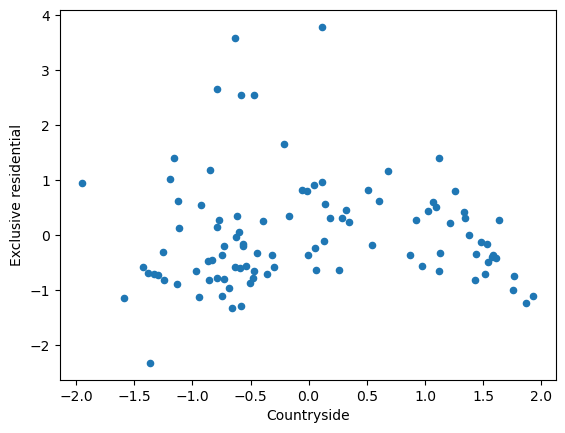

In [12]:
#新しい列の散布図
#都市の非発展度合と住環境の良さ
col=['Countryside','Exclusive residential']
new_df.columns=col
new_df.plot(kind='scatter',x='Countryside',y='Exclusive residential')

In [14]:
model=PCA(whiten=True)
#学習と新機軸へのデータのあてはめを一括で行う
tmp=model.fit_transform(sc_df)
tmp.shape

(100, 14)

In [15]:
#寄与率
model.explained_variance_ratio_

array([0.42769329, 0.15487544, 0.10865349, 0.06821818, 0.0625151 ,
       0.05842945, 0.03126293, 0.02516658, 0.01980351, 0.01694334,
       0.01162264, 0.00984072, 0.00297382, 0.00200152])

<Axes: >

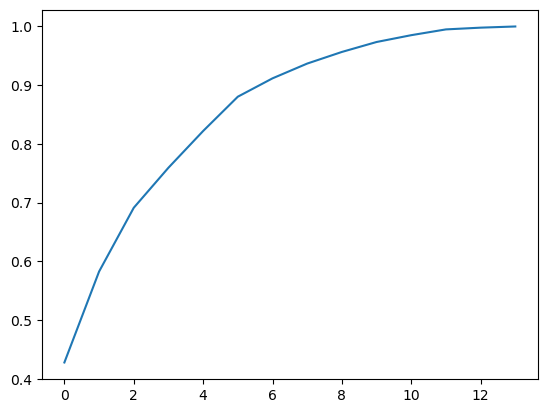

In [16]:
ratio=model.explained_variance_ratio_  #寄与率のデータ集合
array=[]  #第N列までの累積寄与率を格納するリスト
for i in range(len(ratio)):
    ruiseki=sum(ratio[0:(i+1)])
    array.append(ruiseki)
pd.Series(array).plot(kind='line')


In [17]:
thred=0.8  #累積寄与率のしきい値
for i in range(len(array)):
    if array[i]>=thred:
        print(i+1)
        break

5


In [18]:
model=PCA(n_components=5,whiten=True)  #第５主成分までを用いる
model.fit(sc_df)
new=model.transform(sc_df)

In [19]:
col=['PC1','PC2','PC3','PC4','PC5']  #列名の指定
new_df2=pd.DataFrame(new,columns=col)
new_df2.to_csv('boston_pca.csv',index=False)

In [ ]:
#練習問題　3,3,1

In [20]:
#練習問題14-4
import pandas as pd
df=pd.read_csv('../sukkiri-ml2-codes/datafiles/Boston.csv')
df.head(3)

,CRIME,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,LSTAT,PRICE
0,high,0.0,18.10,0,0.718,3.561,87.9,1.6132,24.0,666,20.2,7.12,27.5
1,low,0.0,8.14,0,0.538,5.950,82.0,3.9900,4.0,307,21.0,27.71,13.2
2,very_low,82.5,2.03,0,0.415,6.162,38.4,6.2700,2.0,348,14.7,7.43,24.1
